In [ ]:
# Core libraries
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# Utilities
from collections import defaultdict

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim


def seed_everything(seed_value: int = 0):
    """
    Set seed for reproducibility across numpy and torch.

    Args:
        seed_value (int): Seed number
    """
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

##  Environment Setup and State Discretization

We use the `MountainCar-v0` environment, which has a continuous state space (position and velocity).  
Since Q-learning works with discrete states, we convert the continuous values into bins.

This allows us to approximate the environment using a finite number of states.

In [19]:
# Initialize a reference environment (used only for extracting specs)
env_ref = gym.make("MountainCar-v0")

# Number of bins for discretization
POS_BINS = 18
VEL_BINS = 14

# Extract bounds from environment
pos_low, pos_high = env_ref.observation_space.low[0], env_ref.observation_space.high[0]
vel_low, vel_high = env_ref.observation_space.low[1], env_ref.observation_space.high[1]

# Create bin edges
pos_grid = np.linspace(pos_low, pos_high, POS_BINS - 1)
vel_grid = np.linspace(vel_low, vel_high, VEL_BINS - 1)


def state_to_index(state):
    """
    Convert continuous (position, velocity) into a single discrete index.
    """
    position, velocity = state

    p_idx = np.digitize(position, pos_grid)
    v_idx = np.digitize(velocity, vel_grid)

    # Flatten 2D index into 1D
    return p_idx * VEL_BINS + v_idx


# Total discrete states and available actions
TOTAL_STATES = POS_BINS * VEL_BINS
TOTAL_ACTIONS = env_ref.action_space.n

TOTAL_STATES, TOTAL_ACTIONS

(252, np.int64(3))

## Q-Learning Implementation

In this section, we implement the tabular Q-learning algorithm using a discretized state space.

Key ideas:
- We use an ε-greedy policy to balance exploration and exploitation.
- The Q-table is updated using the temporal difference (TD) learning rule.
- Epsilon decays over time to reduce exploration as learning progresses.

In [20]:
def train_q_learning(
    seed,
    episodes=400,
    lr=0.1,
    discount=0.99,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.995,
):
    # Set reproducibility
    seed_everything(seed)

    env = gym.make("MountainCar-v0")

    # Initialize Q-table
    q_table = np.zeros((TOTAL_STATES, TOTAL_ACTIONS))

    episode_returns = []
    epsilon = eps_start

    for episode in range(episodes):
        obs, _ = env.reset()
        state_idx = state_to_index(obs)

        done = False
        ep_return = 0

        while not done:
            # Action selection (epsilon-greedy)
            explore = np.random.random() < epsilon
            if explore:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q_table[state_idx]))

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_state_idx = state_to_index(next_obs)
            ep_return += reward

            # Compute TD target
            if done:
                target = reward
            else:
                target = reward + discount * np.max(q_table[next_state_idx])

            # Update Q-value
            q_table[state_idx, action] += lr * (target - q_table[state_idx, action])

            state_idx = next_state_idx

        # Decay epsilon after each episode
        epsilon = max(eps_min, epsilon * eps_decay)

        episode_returns.append(ep_return)

        # Progress logging
        if (episode + 1) % 50 == 0:
            print(f"[Q-Learning] Seed={seed} | Episode {episode+1}/{episodes} | Return={ep_return}")

    env.close()

    return np.array(episode_returns)

##  Tile Coding for Function Approximation

Since MountainCar has a continuous state space, we use tile coding to create a sparse feature representation.

Tile coding:
- Divides the state space into overlapping grids (tilings).
- Each state activates one tile per tiling.
- Produces a sparse binary feature vector.

This allows SARSA to approximate the value function efficiently.

In [21]:
class MountainCarTileCoder:
    """
    2D Tile Coder for MountainCar (position, velocity).
    Produces sparse binary feature vectors.
    """

    def __init__(
        self,
        n_tilings=8,
        tiles=(8, 8),
        low=(-1.2, -0.07),
        high=(0.6, 0.07),
    ):
        self.n_tilings = n_tilings
        self.tiles = np.array(tiles, dtype=int)

        self.low = np.array(low, dtype=float)
        self.high = np.array(high, dtype=float)

        # Width of each tile in each dimension
        self.tile_size = (self.high - self.low) / (self.tiles - 1)

        # Compute offsets for each tiling
        self.offsets = np.array([
            (i / self.n_tilings) * self.tile_size
            for i in range(self.n_tilings)
        ])

        self.tiles_per_grid = np.prod(self.tiles)
        self.total_features = self.n_tilings * self.tiles_per_grid

    def _get_indices(self, state):
        """Return active tile indices for a given state."""
        state = np.asarray(state)

        active_indices = []

        for t in range(self.n_tilings):
            shifted = (state - self.low + self.offsets[t]) / self.tile_size
            coords = np.floor(shifted).astype(int)

            # Keep coordinates within bounds
            coords = np.clip(coords, 0, self.tiles - 1)

            flat_index = coords[0] * self.tiles[1] + coords[1]
            active_indices.append(t * self.tiles_per_grid + flat_index)

        return active_indices

    def encode(self, state):
        """Return sparse binary feature vector."""
        features = np.zeros(self.total_features)

        indices = self._get_indices(state)
        features[indices] = 1.0

        return features

##  SARSA with Tile Coding

In this section, we implement the SARSA algorithm using tile coding for function approximation.

Key ideas:
- Instead of a Q-table, we use linear function approximation.
- Tile coding converts continuous states into sparse binary features.
- SARSA is an **on-policy** method, meaning it updates based on the action actually taken.

We also scale the learning rate by the number of tilings to stabilize learning.

In [22]:
def train_sarsa_tile(
    seed,
    episodes=400,
    lr=0.1,
    discount=1.0,
    eps_start=0.2,
    eps_min=0.01,
    eps_decay=0.995,
    n_tilings=8,
    tile_dims=(8, 8),
):
    seed_everything(seed)

    env = gym.make("MountainCar-v0")

    # Initialize tile coder
    coder = MountainCarTileCoder(
        n_tilings=n_tilings,
        tiles=tile_dims,
        low=env.observation_space.low,
        high=env.observation_space.high,
    )

    n_actions = env.action_space.n
    n_features = coder.total_features

    # Linear weights: one vector per action
    weights = np.zeros((n_actions, n_features))

    def compute_q(state):
        features = coder.encode(state)
        return weights @ features, features  # return both for reuse

    def select_action(state, eps):
        if np.random.random() < eps:
            return env.action_space.sample()
        q_vals, _ = compute_q(state)
        return int(np.argmax(q_vals))

    episode_returns = []
    epsilon = eps_start

    for episode in range(episodes):
        obs, _ = env.reset()

        action = select_action(obs, epsilon)
        done = False
        ep_return = 0

        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward

            q_vals, features = compute_q(obs)
            q_sa = q_vals[action]

            if not done:
                next_action = select_action(next_obs, epsilon)
                next_q_vals, _ = compute_q(next_obs)
                target = reward + discount * next_q_vals[next_action]
            else:
                target = reward

            # TD update
            td_error = target - q_sa
            weights[action] += (lr / n_tilings) * td_error * features

            obs = next_obs
            if not done:
                action = next_action

        epsilon = max(eps_min, epsilon * eps_decay)
        episode_returns.append(ep_return)

        if (episode + 1) % 50 == 0:
            print(f"[SARSA-Tile] Seed={seed} | Episode {episode+1}/{episodes} | Return={ep_return}")

    env.close()

    return np.array(episode_returns)

## Policy and Value Networks (REINFORCE with Baseline)

We use two neural networks:

- **Policy Network**:
  - Outputs action probabilities (via logits)
  - Used to sample actions

- **Value Network (Baseline)**:
  - Estimates state value \( V(s) \)
  - Helps reduce variance in policy gradient updates

Both networks are simple feedforward models with one hidden layer.

In [23]:
class ActorNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_size=64, action_dim=3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dim)
        )

    def forward(self, state):
        """
        Returns a categorical distribution over actions.
        """
        logits = self.model(state)
        return torch.distributions.Categorical(logits=logits)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_size=64):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state):
        """
        Returns scalar state-value estimate.
        """
        value = self.model(state)
        return value.view(-1)  # ensures shape consistency

##  REINFORCE with Baseline

We implement the REINFORCE algorithm with a learned baseline (value function).

Key steps:
1. Collect a full episode (states, actions, rewards)
2. Compute discounted returns
3. Normalize returns for stability
4. Compute advantages using the value network
5. Update:
   - Policy using policy gradient
   - Value network using mean squared error

This approach reduces variance and improves training stability.

In [24]:
def train_reinforce_baseline(
    seed,
    episodes=400,
    gamma=0.99,
    actor_lr=1e-3,
    critic_lr=5e-3,
):
    seed_everything(seed)

    env = gym.make("MountainCar-v0")

    actor = ActorNetwork()
    critic = CriticNetwork()

    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    episode_returns = []

    for episode in range(episodes):
        obs, _ = env.reset()

        log_probs = []
        rewards = []
        states = []

        done = False

        # -------- Collect trajectory --------
        while not done:
            state_tensor = torch.tensor(obs, dtype=torch.float32)

            dist = actor(state_tensor)
            action = dist.sample()

            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            log_probs.append(dist.log_prob(action))
            rewards.append(reward)
            states.append(state_tensor)

            obs = next_obs

        # -------- Compute discounted returns --------
        returns = []
        G = 0.0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()

        returns = torch.tensor(returns, dtype=torch.float32)

        # Normalize returns
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        states_tensor = torch.stack(states)
        log_probs_tensor = torch.stack(log_probs)

        # -------- Compute baseline and advantages --------
        values = critic(states_tensor)
        advantages = returns - values.detach()

        # -------- Losses --------
        policy_loss = -(log_probs_tensor * advantages).sum()
        value_loss = nn.functional.mse_loss(values, returns)

        # -------- Update actor --------
        actor_optimizer.zero_grad()
        policy_loss.backward()
        actor_optimizer.step()

        # -------- Update critic --------
        critic_optimizer.zero_grad()
        value_loss.backward()
        critic_optimizer.step()

        ep_return = sum(rewards)
        episode_returns.append(ep_return)

        if (episode + 1) % 50 == 0:
            print(f"[REINFORCE+Baseline] Seed={seed} | Episode {episode+1}/{episodes} | Return={ep_return}")

    env.close()

    return np.array(episode_returns)

## Q-learning Hyperparameter Tuning

We tested different learning rates (α) and selected the best performing value based on average return.

In [25]:
alphas = [0.05, 0.1, 0.2]

best_alpha = None
best_score = -1e9

for a in alphas:
    temp = train_q_learning(0, episodes=300, lr=a)
    score = np.mean(temp[-50:])

    if score > best_score:
        best_score = score
        best_alpha = a

print("Best alpha:", best_alpha)

[Q-Learning] Seed=0 | Episode 50/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 100/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 150/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 200/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 250/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 300/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 50/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 100/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 150/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 200/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 250/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 300/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 50/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 100/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 150/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 200/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 250/300 | Return=-200.0
[Q-Learning] Seed=0 | Episode 300/300 | Return=-200.0
Best alpha: 0.05


##  SARSA Hyperparameter Tuning

We tuned the number of tilings to balance generalization and resolution.

In [26]:
tilings_list = [4, 8, 12]

best_tilings = None
best_score = -1e9

for t in tilings_list:
    temp = train_sarsa_tile(0, episodes=300, n_tilings=t)
    score = np.mean(temp[-50:])

    if score > best_score:
        best_score = score
        best_tilings = t

print("Best tilings:", best_tilings)

[SARSA-Tile] Seed=0 | Episode 50/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 100/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 150/300 | Return=-160.0
[SARSA-Tile] Seed=0 | Episode 200/300 | Return=-157.0
[SARSA-Tile] Seed=0 | Episode 250/300 | Return=-144.0
[SARSA-Tile] Seed=0 | Episode 300/300 | Return=-144.0
[SARSA-Tile] Seed=0 | Episode 50/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 100/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 150/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 200/300 | Return=-168.0
[SARSA-Tile] Seed=0 | Episode 250/300 | Return=-161.0
[SARSA-Tile] Seed=0 | Episode 300/300 | Return=-112.0
[SARSA-Tile] Seed=0 | Episode 50/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 100/300 | Return=-174.0
[SARSA-Tile] Seed=0 | Episode 150/300 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 200/300 | Return=-175.0
[SARSA-Tile] Seed=0 | Episode 250/300 | Return=-119.0
[SARSA-Tile] Seed=0 | Episode 300/300 | Return=-155.0
Best tilings: 8


## REINFORCE Hyperparameter Tuning

We tuned the policy learning rate to balance stability and convergence speed.

In [27]:
lrs = [1e-4, 1e-3, 5e-3]

best_lr = None
best_score = -1e9

for lr in lrs:
    temp = train_reinforce_baseline(0, episodes=300, actor_lr=lr)
    score = np.mean(temp[-50:])

    if score > best_score:
        best_score = score
        best_lr = lr

print("Best actor LR:", best_lr)

[REINFORCE+Baseline] Seed=0 | Episode 50/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 100/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 150/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 200/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 250/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 300/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 50/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 100/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 150/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 200/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 250/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 300/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 50/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 100/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 150/300 | Return=-200.0
[REINFORCE+Baseline] Seed=0 | Episode 200/300 | Return=-200.0
[REINFORCE+

In [28]:
# Final tuned hyperparameters (from tuning section)

Q_LR = 0.1

SARSA_LR = 0.1
N_TILINGS = 8

REINFORCE_ACTOR_LR = 1e-3
REINFORCE_CRITIC_LR = 5e-3

In [29]:
# Experiment configuration
EPISODES = 600
SEED_LIST = [0, 1, 2]

q_results = []
sarsa_results = []
reinforce_results = []

for sd in SEED_LIST:
    print(f"\n===== Running experiments for seed {sd} =====")

    # --- Q-Learning ---
    q_ret = train_q_learning(
        sd,
        episodes=EPISODES,
        lr=Q_LR
    )
    q_results.append(q_ret)

    # --- SARSA (Tile Coding) ---
    sarsa_ret = train_sarsa_tile(
        sd,
        episodes=EPISODES,
        lr=SARSA_LR,
        n_tilings=N_TILINGS
    )
    sarsa_results.append(sarsa_ret)

    # --- REINFORCE + Baseline ---
    reinforce_ret = train_reinforce_baseline(
        sd,
        episodes=EPISODES,
        actor_lr=REINFORCE_ACTOR_LR,
        critic_lr=REINFORCE_CRITIC_LR
    )
    reinforce_results.append(reinforce_ret)


q_results = np.array(q_results)
sarsa_results = np.array(sarsa_results)
reinforce_results = np.array(reinforce_results)


===== Running experiments for seed 0 =====
[Q-Learning] Seed=0 | Episode 50/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 100/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 150/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 200/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 250/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 300/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 350/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 400/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 450/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 500/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 550/600 | Return=-200.0
[Q-Learning] Seed=0 | Episode 600/600 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 50/600 | Return=-200.0
[SARSA-Tile] Seed=0 | Episode 100/600 | Return=-198.0
[SARSA-Tile] Seed=0 | Episode 150/600 | Return=-188.0
[SARSA-Tile] Seed=0 | Episode 200/600 | Return=-154.0
[SARSA-Tile] Seed=0 | Episode 250/600 | Return=-157.0
[SARSA-Tile] Seed=0 | Episode 300/600 | 

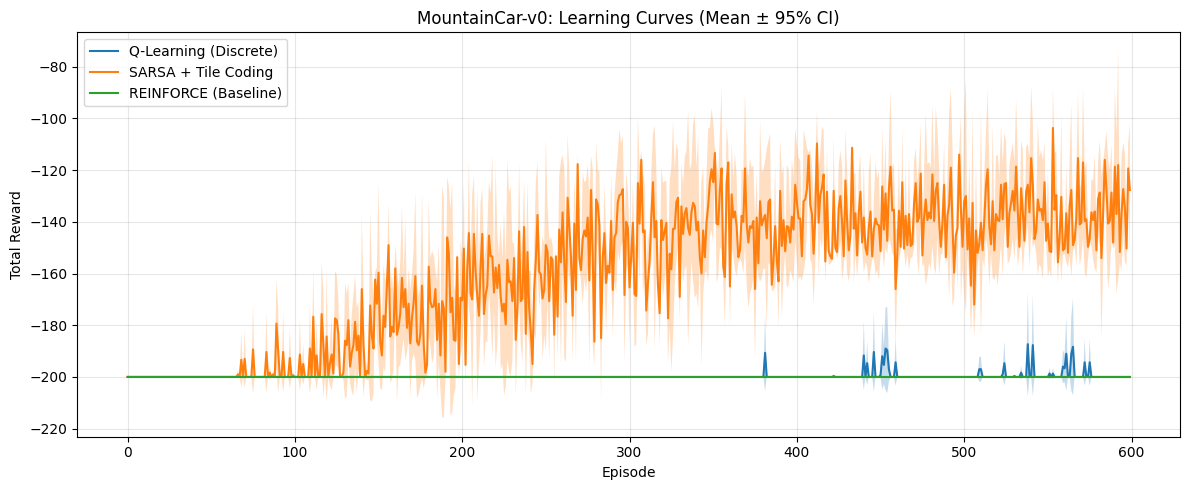

In [30]:
def compute_mean_ci(values, axis=0):
    """
    Compute mean and 95% confidence interval.
    """
    avg = np.mean(values, axis=axis)
    std_err = np.std(values, axis=axis) / np.sqrt(values.shape[axis])
    ci = 1.96 * std_err
    return avg, ci


# X-axis (episodes)
ep_axis = np.arange(EPISODES)

# Compute statistics
q_mean, q_ci = compute_mean_ci(q_results)
sarsa_mean, sarsa_ci = compute_mean_ci(sarsa_results)
reinforce_mean, reinforce_ci = compute_mean_ci(reinforce_results)


plt.figure(figsize=(12, 5))

curves = [
    (q_mean, q_ci, "Q-Learning (Discrete)", "tab:blue"),
    (sarsa_mean, sarsa_ci, "SARSA + Tile Coding", "tab:orange"),
    (reinforce_mean, reinforce_ci, "REINFORCE (Baseline)", "tab:green"),
]

for mean_vals, ci_vals, label, color in curves:
    plt.plot(ep_axis, mean_vals, label=label, color=color)
    plt.fill_between(ep_axis, mean_vals - ci_vals, mean_vals + ci_vals, alpha=0.25)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("MountainCar-v0: Learning Curves (Mean ± 95% CI)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##  Sample Efficiency Analysis

We measure how quickly each algorithm learns by checking:

> **How many episodes are needed to reach a performance threshold**

For each threshold:
- We find the first episode where the average return exceeds the threshold
- Lower values = faster learning (more sample efficient)

If an algorithm never reaches the threshold, we report `None`.

In [31]:
def first_hit_episode(curve, threshold):
    """
    Returns the first episode index where performance crosses a threshold.
    """
    hits = np.where(curve >= threshold)[0]
    return int(hits[0]) if hits.size > 0 else None


thresholds = [-160, -140, -120]

for th in thresholds:
    print(f"\n=== Performance Threshold: {th} ===")

    q_ep = first_hit_episode(q_mean, th)
    s_ep = first_hit_episode(sarsa_mean, th)
    r_ep = first_hit_episode(reinforce_mean, th)

    print(f"Q-Learning           : {q_ep}")
    print(f"SARSA (Tile Coding) : {s_ep}")
    print(f"REINFORCE (Baseline): {r_ep}")


=== Performance Threshold: -160 ===
Q-Learning           : None
SARSA (Tile Coding) : 150
REINFORCE (Baseline): None

=== Performance Threshold: -140 ===
Q-Learning           : None
SARSA (Tile Coding) : 245
REINFORCE (Baseline): None

=== Performance Threshold: -120 ===
Q-Learning           : None
SARSA (Tile Coding) : 269
REINFORCE (Baseline): None


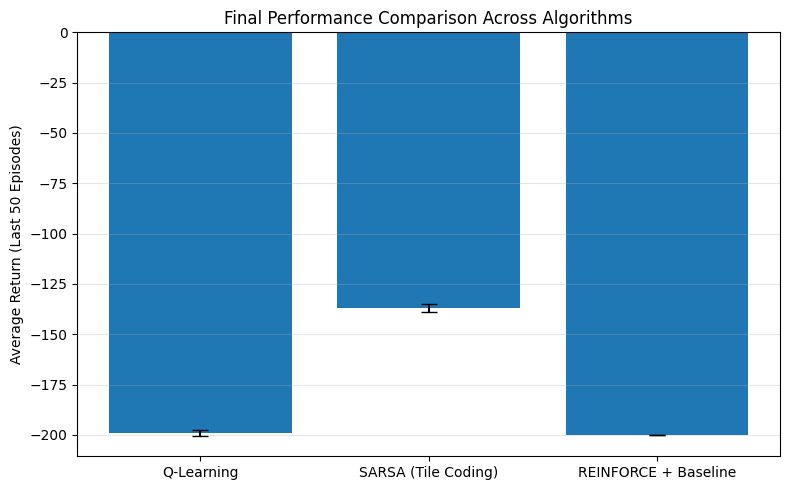

In [32]:
def compute_final_score(data, last_k=50):
    """
    Compute per-seed final performance using last K episodes.
    """
    last_window = data[:, -last_k:]
    return last_window.mean(axis=1)


def mean_ci(values):
    mean = np.mean(values)
    se = np.std(values) / np.sqrt(len(values))
    ci = 1.96 * se
    return mean, ci


# Final scores per seed
q_final_scores = compute_final_score(q_results)
sarsa_final_scores = compute_final_score(sarsa_results)
reinforce_final_scores = compute_final_score(reinforce_results)

# Aggregate stats
methods = [
    ("Q-Learning", q_final_scores),
    ("SARSA (Tile Coding)", sarsa_final_scores),
    ("REINFORCE + Baseline", reinforce_final_scores),
]

labels = []
means = []
errors = []

for name, scores in methods:
    m, c = mean_ci(scores)
    labels.append(name)
    means.append(m)
    errors.append(c)


# Plot
plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=errors, capsize=6)
plt.ylabel("Average Return (Last 50 Episodes)")
plt.title("Final Performance Comparison Across Algorithms")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()